In [1]:
!pip install nltk

In [2]:
!pip install wordcloud

In [3]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
toxic = pd.read_csv("train.csv")

hate = pd.read_csv("labeled_data.csv")

In [5]:
toxic.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [6]:
hate.head(10)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...
8,8,3,0,3,0,1,""" &amp; you might not get ya bitch back &amp; ..."
9,9,3,1,2,0,1,""" @rhythmixx_ :hobbies include: fighting Maria..."


In [7]:
toxic['label'] = toxic[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].max(axis=1)

toxic = toxic[['comment_text','label']]

In [8]:
toxic.head(10)

,comment_text,label
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
5,"""\n\nCongratulations from me as well, use the ...",0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,Your vandalism to the Matt Shirvington article...,0
8,Sorry if the word 'nonsense' was offensive to ...,0
9,alignment on this subject and which are contra...,0


0 = hate speech
1 = offensive
2 = normal

In [9]:
hate['label'] = hate['class'].apply(lambda x: 0 if x==2 else 1)

hate = hate.rename(columns={'tweet':'comment_text'})

hate = hate[['comment_text','label']]

In [10]:
hate.head(10)

,comment_text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",1
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",1
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,1
8,""" &amp; you might not get ya bitch back &amp; ...",1
9,""" @rhythmixx_ :hobbies include: fighting Maria...",1


In [11]:
data = pd.concat([toxic, hate], ignore_index=True)

data = data.sample(frac=1).reset_index(drop=True)

print("Total comments:",len(data))

Total comments: 184354


In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [13]:
data['clean_text'] = data['comment_text'].apply(clean_text)

In [14]:
data.head(10)

,comment_text,label,clean_text
0,Sex should be a reward in a relationship. Nigg...,1,sex reward relationship nigga never done anyth...
1,"Oh wait, you're an American asshole... Let me ...",1,oh wait american asshole let explain law work ...
2,"Alright, I consolidated the list into the main...",0,alright consolidated list main entry thanks help
3,"""Ekantik, do you believe that Sathya Sai Baba ...",0,ekantik believe sathya sai baba miraculously t...
4,Merry Christmas \n\nI just wanted to wish you ...,0,merry christmas wanted wish merry christmas de...
5,whether there might be clashes with other para...,0,whether might clashes parameters
6,"""\nSockpuppetry case\n \nYou have been accused...",0,sockpuppetry case accused sockpuppetry please ...
7,"As you can see, I removed this statement out o...",0,see removed statement definition also made def...
8,"""\n\nHere's the email I sent the admin who blo...",0,email sent admin blocked ip permanently withou...
9,What source is anti-Jewish? Please clarify. Bh...,0,source anti jewish please clarify bhaisaab talk


In [15]:
vectorizer = TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X = vectorizer.fit_transform(data['clean_text'])

y = data['label']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

In [18]:
pred = nb.predict(X_test)

bayes_acc = accuracy_score(y_test,pred)
print("Bayes_Accuracy:", bayes_acc)

print(classification_report(y_test,pred))

Bayes_Accuracy: 0.939979930026308
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     29598
           1       0.89      0.80      0.84      7273

    accuracy                           0.94     36871
   macro avg       0.92      0.89      0.90     36871
weighted avg       0.94      0.94      0.94     36871



In [19]:
model = LogisticRegression(max_iter=200)

model.fit(X_train,y_train)

LogisticRegression(max_iter=200)

In [20]:
pred = model.predict(X_test)

logistic_acc = accuracy_score(y_test,pred)
print("Logistic_Accuracy:", logistic_acc)

print(classification_report(y_test,pred))

Logistic_Accuracy: 0.9565240975292235
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     29598
           1       0.96      0.81      0.88      7273

    accuracy                           0.96     36871
   macro avg       0.96      0.90      0.93     36871
weighted avg       0.96      0.96      0.96     36871



In [21]:
svm = LinearSVC()

svm.fit(X_train,y_train)

LinearSVC()

In [22]:
pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test,pred)
print("SVM_Accuracy:", svm_acc)

print(classification_report(y_test,pred))

SVM_Accuracy: 0.957717447316319
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     29598
           1       0.94      0.84      0.89      7273

    accuracy                           0.96     36871
   macro avg       0.95      0.91      0.93     36871
weighted avg       0.96      0.96      0.96     36871



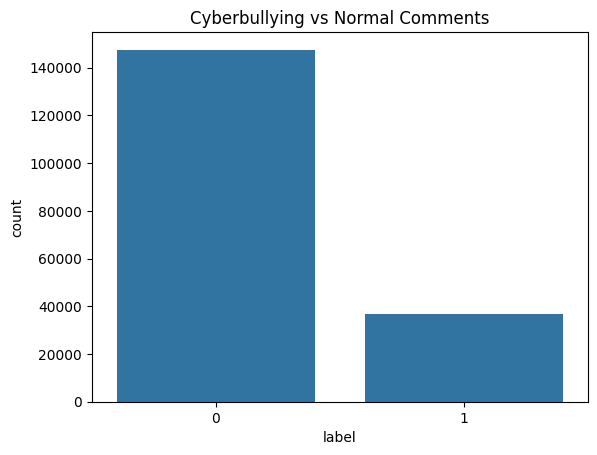

In [23]:
sns.countplot(x=data['label'])

plt.title("Cyberbullying vs Normal Comments")

plt.show()

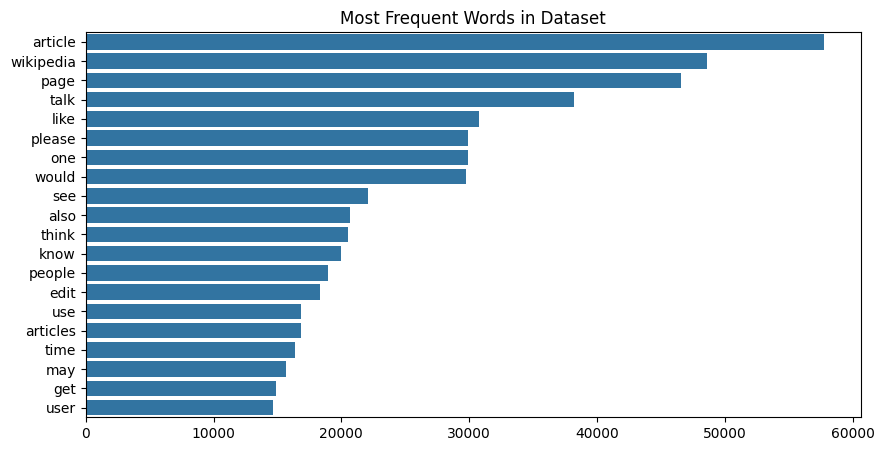

In [24]:
from collections import Counter

words = " ".join(data['clean_text']).split()

common_words = Counter(words).most_common(20)

words = [i[0] for i in common_words]

counts = [i[1] for i in common_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts,y=words)

plt.title("Most Frequent Words in Dataset")

plt.show()

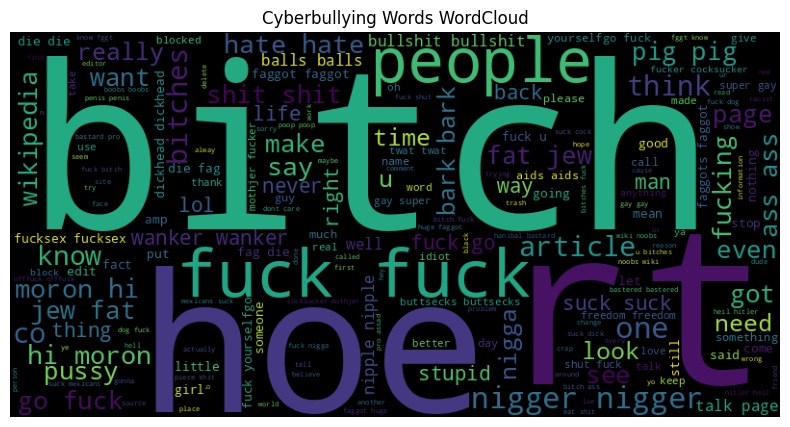

In [25]:
from wordcloud import WordCloud

text = " ".join(data[data['label']==1]['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Cyberbullying Words WordCloud")

plt.show()

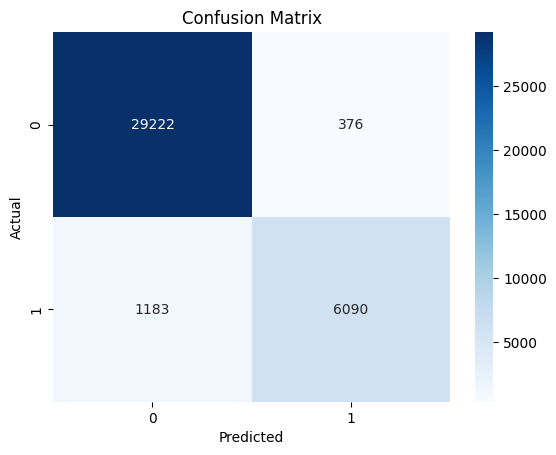

In [26]:
from sklearn.metrics import confusion_matrix

svm_pred = svm.predict(X_test)

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

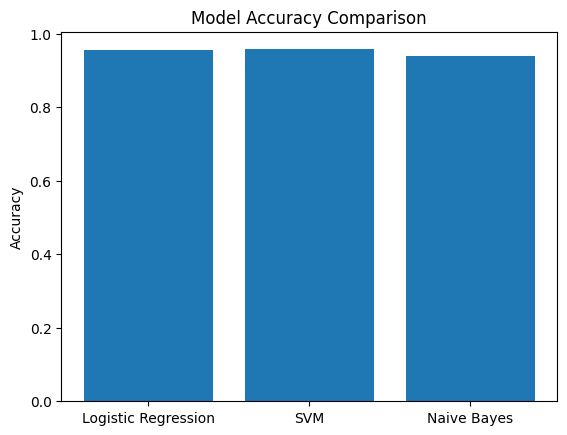

In [27]:
models = ["Logistic Regression","SVM","Naive Bayes"]

scores = [logistic_acc, svm_acc, bayes_acc]

plt.bar(models,scores)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [28]:
bad_words = [
"kill yourself",
"suicide",
"die",
"ugly",
"loser",
"idiot",
"worthless",
"stupid",
"moron",
"hate you"
]

In [29]:
def keyword_check(text):

    text = text.lower()

    for word in bad_words:

        if word in text:

            return True

    return False

In [30]:
def detect_comment(comment):

    print("User Comment:",comment)

    if keyword_check(comment):

        print("⚠ Harmful keyword detected")
        print("❌ Comment BLOCKED")
        return

    cleaned = clean_text(comment)

    vector = vectorizer.transform([cleaned])

    prediction = svm.predict(vector)

    if prediction[0] == 1:

        print("🚫 Cyberbullying detected")
        print("❌ Comment BLOCKED")

    else:

        print("✅ Safe Comment Posted")

In [31]:
detect_comment("you are ugly and useless")

User Comment: you are ugly and useless
⚠ Harmful keyword detected
❌ Comment BLOCKED


In [32]:
detect_comment("go kill yourself")

User Comment: go kill yourself
⚠ Harmful keyword detected
❌ Comment BLOCKED


In [33]:
detect_comment("great video nice work")

User Comment: great video nice work
✅ Safe Comment Posted
